# DL071 分布外鲁棒性与不确定性

本Notebook从零重训三个CPU模型，校准只使用校准集，所有测试域事先固定。输出另存notebook_outputs。图来自本次执行。

In [1]:
from pathlib import Path
import json, numpy as np, torch
import matplotlib.pyplot as plt
from experiment import run, selective, model, logits, softmax
torch.set_num_threads(1)
print("PyTorch", torch.__version__, "device=cpu, threads=1")
from io import BytesIO
from IPython.display import Image, display
def show(fig):
    buffer=BytesIO()
    fig.savefig(buffer,format="png",dpi=140,bbox_inches="tight")
    display(Image(data=buffer.getvalue()))
    plt.close(fig)

PyTorch 2.14.1+cpu device=cpu, threads=1


## 1 先验证一个有明确分母的手算
阈值0.75接受两条，其中一条错误。

In [2]:
p=np.array([[.9,.1],[.2,.8],[.7,.3],[.4,.6]])
y=np.array([0,0,0,1])
for tau in [.75,0.,1.]:
    print(tau, selective(p,y,tau))

0.75 {'n': 4, 'accepted': 2, 'errors_accepted': 1, 'threshold': 0.75, 'coverage': 0.5, 'risk': 0.5, 'risk_wilson95': [0.09452865480086614, 0.9054713451991339], 'full_error': 0.25}
0.0 {'n': 4, 'accepted': 4, 'errors_accepted': 1, 'threshold': 0.0, 'coverage': 1.0, 'risk': 0.25, 'risk_wilson95': [0.045586062644636216, 0.6993639475573634], 'full_error': 0.25}
1.0 {'n': 4, 'accepted': 0, 'errors_accepted': 0, 'threshold': 1.0, 'coverage': 0.0, 'risk': None, 'risk_wilson95': None, 'full_error': 0.25}


## 2 实际训练与校准
这里不是读取预置图；执行完整默认训练。

In [3]:
result=run("notebook_outputs")
print("Trained",len(result["runs"]),"models")
for r in result["runs"]:
    print("seed",r["seed"],"temperature",r["temperature"],"threshold",r["threshold"])

Trained 3 models
seed 17 temperature 0.5 threshold 0.9999999811217154
seed 29 temperature 0.5 threshold 0.9999999927748993
seed 43 temperature 0.5 threshold 0.9999999976228187


## 3 逐域计数与空接受集
输出null对应Python None，不能解释成零风险。

In [4]:
first=result["runs"][0]
for name,values in first["domains"].items():
    s=values["selective"]
    print(name,"accepted",s["accepted"],"coverage",s["coverage"],"risk",s["risk"])

id accepted 463 coverage 0.7716666666666666 risk 0.0
core_noise accepted 386 coverage 0.6433333333333333 risk 0.0
shortcut_fade accepted 0 coverage 0.0 risk None
shortcut_flip accepted 314 coverage 0.5233333333333333 risk 1.0
subgroup_flip accepted 427 coverage 0.7116666666666667 risk 0.17330210772833723


## 4 重载全部权重
只加载可信课程或自己生成的文件；这些是推理checkpoint。

In [5]:
root=Path("notebook_outputs")
data=np.load(root/"data.npz")
pred=np.load(root/"predictions.npz")
for r in result["runs"]:
    ck=torch.load(root/f"model_seed{r['seed']}.pt",weights_only=True)
    m=model(); m.load_state_dict(ck["state_dict"])
    q=softmax(logits(m,data["shortcut_flip_x"]),ck["temperature"])
    np.testing.assert_array_equal(q,pred[f"seed{r['seed']}_shortcut_flip_p"])
print("All three checkpoint predictions match exactly")

All three checkpoint predictions match exactly


## 5 绘制本次执行的风险覆盖曲线
全部测试阈值只用于描述曲线，不据此挑部署阈值。

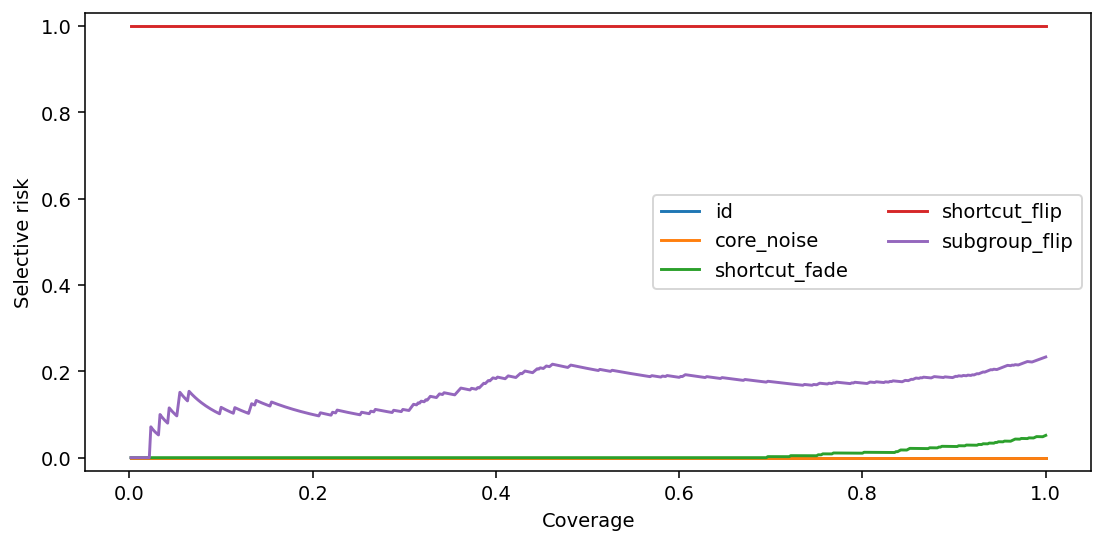

In [6]:
fig,ax=plt.subplots(figsize=(8,4))
for name,v in first["domains"].items():
    curve=v["risk_coverage"];ax.plot(curve["coverage"],curve["risk"],label=name)
ax.set(xlabel="Coverage",ylabel="Selective risk",ylim=(-.03,1.03))
ax.legend(ncol=2);fig.tight_layout();show(fig)

## 6 温度选择与置信但错误
左图只用校准集，右图使用反转测试标签评估。

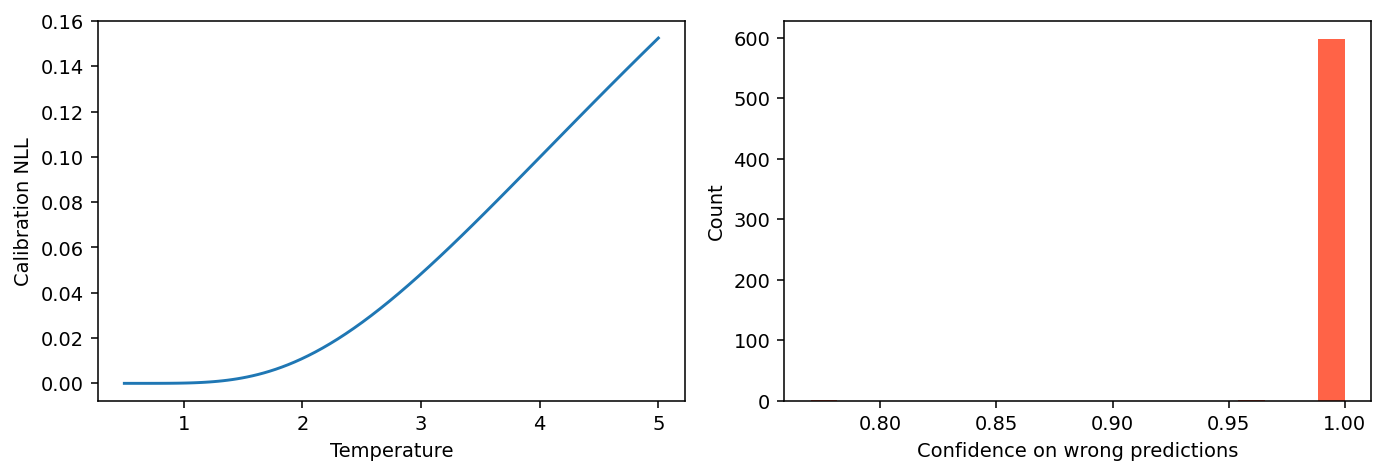

{'index': 0, 'x': [1.867340326309204, -2.4543890953063965], 'y': 1, 'prediction': 0, 'confidence': 0.9999999872779092}


In [7]:
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
search=first["calibration_search"]
axes[0].plot(search["temperatures"],search["nll"]);axes[0].set(xlabel="Temperature",ylabel="Calibration NLL")
q=pred["seed17_shortcut_flip_p"];wrong=q.argmax(1)!=data["test_y"]
axes[1].hist(q.max(1)[wrong],bins=20,color="tomato");axes[1].set(xlabel="Confidence on wrong predictions",ylabel="Count")
fig.tight_layout();show(fig)
print(first["domains"]["shortcut_flip"]["confident_wrong_examples"][0])

## 7 与固定结果核对
只比较确定性数值，耗时不应强求相同。

In [8]:
reference=json.loads(Path("outputs/results.json").read_text())
for a,b in zip(result["runs"],reference["runs"]):
    np.testing.assert_allclose(a["losses"],b["losses"],rtol=1e-6,atol=1e-8)
    for name in a["domains"]:
        if a["domains"][name]["selective"]!=b["domains"][name]["selective"]:
            raise RuntimeError("Selective metrics differ: "+name)
print("Deterministic losses and selective reports match reference")

Deterministic losses and selective reports match reference


## 结论边界
同分布校准、低熵和成员一致都不保证分布外正确。这个实验未验证真实用户、自然图像或对抗攻击，也没有实现风险上界控制。